In [67]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style="whitegrid")

In [69]:
historical_data=pd.read_csv("historical_data.csv")
fear_greed_data=pd.read_csv("fear_greed_index.csv")

In [70]:
# historical_data.info()
historical_data.columns
# historical_data.isnull().sum()  # for check null values

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [71]:
# fear_greed_data.info()
# fear_greed_data.isnull().sum()
# fear_greed_data.columns
fear_greed_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [72]:
historical_data.columns = historical_data.columns.str.lower().str.replace(" ", "_")
historical_data.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [73]:
historical_data["timestamp_ist"]=pd.to_datetime(historical_data["timestamp_ist"],dayfirst=True)  


In [78]:
historical_data["date"]=pd.to_datetime(historical_data["timestamp_ist"]).dt.date  # convert the column in date time

In [79]:
fear_greed_data["date"]=pd.to_datetime(fear_greed_data["date"]).dt.date    # convert the column in date time

In [80]:
daily_pnl= historical_data.groupby("date")["closed_pnl"].sum().reset_index()   # calculate every day profit loss
print(daily_pnl["date"].dtype)
print(fear_greed_data["date"].dtype)

object
object


In [81]:
merged_data=pd.merge(
    daily_pnl,
    fear_greed_data[["date","classification","value"]],
    on="date",
    how="inner"
)
merged_data["date_str"]=merged_data["date"].astype(str)     # merge the both dataset

In [82]:
merged_data[["closed_pnl", "value"]].corr()  #  for find correlation between closed_pnl and value column

,closed_pnl,value
closed_pnl,1.000000,-0.082642
value,-0.082642,1.000000


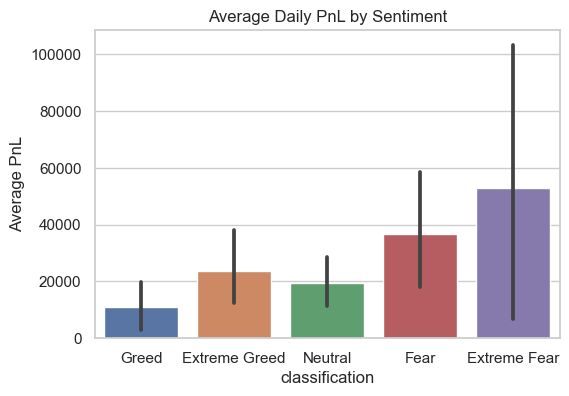

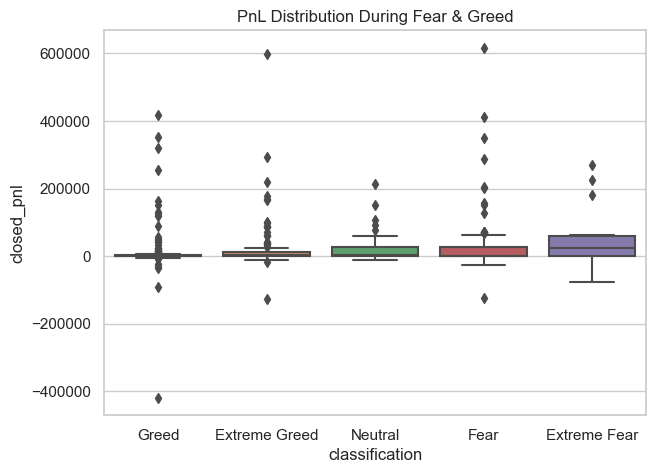

In [83]:
# Barplot - Average Daily Profit and loss  by Sentiment
plt.figure(figsize=(6, 4))
sns.barplot(
    data=merged_data,
    x="classification",
    y="closed_pnl"          # daily profit and loss"
)
plt.title("Average Daily PnL by Sentiment")
plt.ylabel("Average PnL")
plt.show()

# Boxplot - Profit and loss Distribution
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=merged_data,
    x="classification",
    y="closed_pnl"          # daily profit and loss
)
plt.title("PnL Distribution During Fear & Greed")
plt.show()

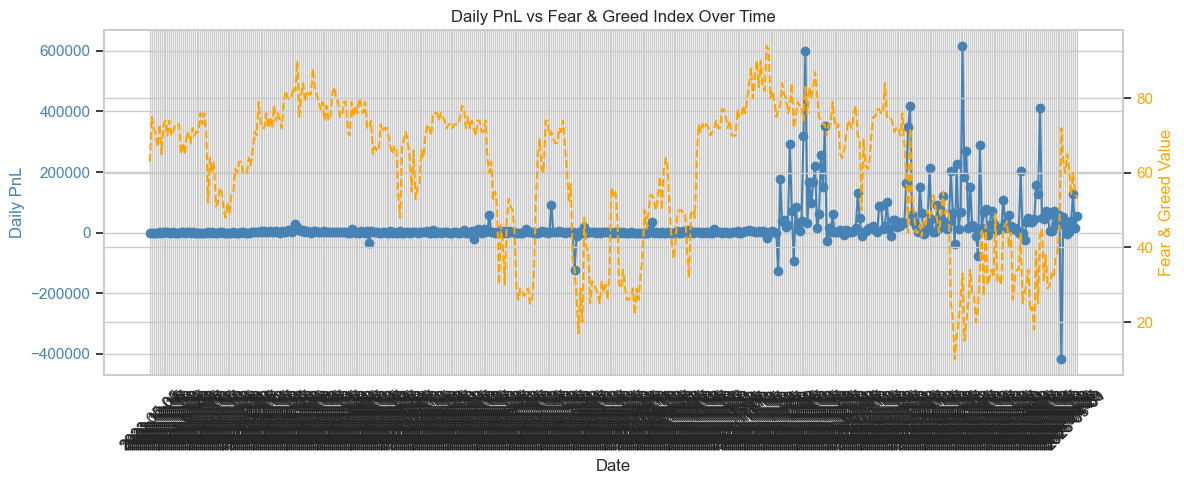

In [84]:
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(merged_data["date_str"],
         merged_data["closed_pnl"],
         color="steelblue", 
         marker="o", 
         label="PnL"
        )
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily PnL", color="steelblue")

ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(merged_data["date_str"],
         merged_data["value"], 
         color="orange", 
         linestyle="--", 
         label="F&G Index"
        )
ax2.set_ylabel("Fear & Greed Value", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Daily PnL vs Fear & Greed Index Over Time")
fig.tight_layout()
plt.show()

In [85]:
merged_data.groupby("classification")["closed_pnl"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
classification,,,,
Extreme Fear,52793.589178,22561.739636,101262.394065,14
Extreme Greed,23817.292199,3127.536297,72827.301581,114
Fear,36891.818040,1412.314654,96611.848503,91
Greed,11140.566181,678.475928,62427.957949,193
Neutral,19297.323516,1818.573295,37995.209071,67


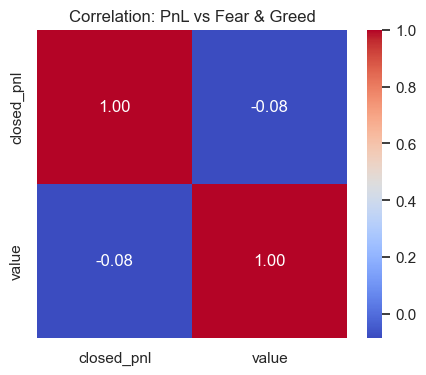

In [86]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    merged_data[["closed_pnl", "value"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation: PnL vs Fear & Greed")
plt.show()

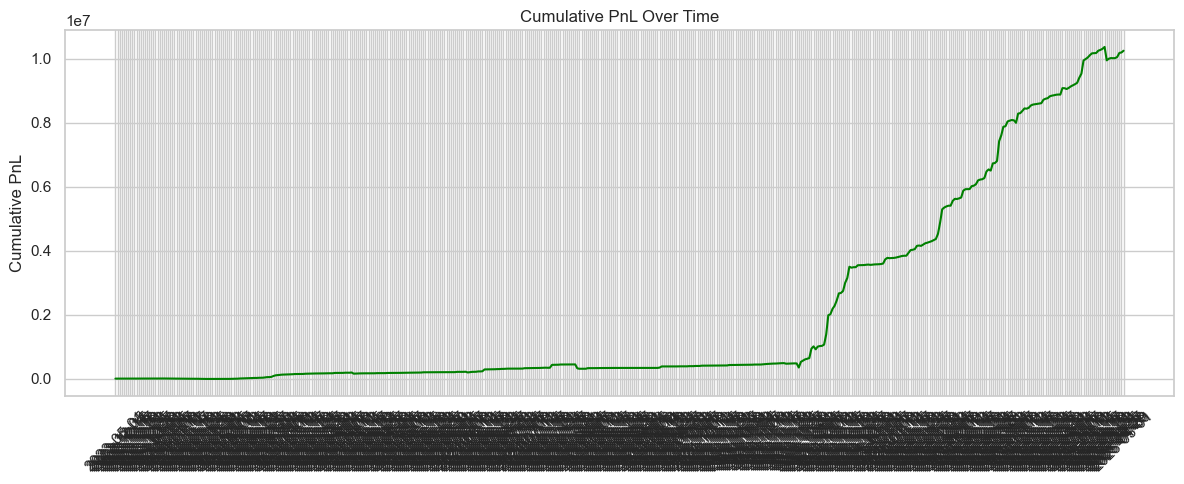

In [87]:
merged_data_sorted = merged_data.sort_values("date")
merged_data_sorted["cumulative_pnl"] = merged_data_sorted["closed_pnl"].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(merged_data_sorted["date_str"], 
         merged_data_sorted["cumulative_pnl"],
         color="green"
        )
plt.xticks(rotation=45)
plt.title("Cumulative PnL Over Time")
plt.ylabel("Cumulative PnL")
plt.tight_layout()
plt.show()